<a href="https://colab.research.google.com/github/SeeYoong/DiffractGPT/blob/MyEdit/jarvis-tools-notebooks/DiffractGPT_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[DiffractGPT: Atomic Structure Determination from X‑ray DiffractionPatterns Using a Generative Pretrained Transformer](https://pubs.acs.org/doi/epdf/10.1021/acs.jpclett.4c03137)

Author email: kamal.choudhary@nist.gov



In [1]:
%time
# !pip install  -q dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
# !pip install -q alignn
!pip install -q atomgpt bitsandbytes ase


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.91 µs
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 845.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 M

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
model_id = "knc6/diffractgpt_mistral_chemical_formula"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/732 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

Unused kwargs: ['_load_in_4bit', '_load_in_8bit', 'quant_method']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.
`low_cpu_mem_usage` was None, now default to True since model is quantized.


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

In [10]:
%%time
from jarvis.analysis.diffraction.xrd import XRD
from jarvis.core.atoms import Atoms
from jarvis.db.figshare import get_jid_data
import numpy as np
import torch
from jarvis.core.lattice import Lattice
from matplotlib.gridspec import GridSpec
from sklearn.metrics import mean_absolute_error
from ase.visualize import view
import time
from scipy import stats
from ase.optimize.fire import FIRE
from ase.constraints import ExpCellFilter
from jarvis.io.vasp.inputs import Poscar
from jarvis.core.atoms import ase_to_atoms
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
import pandas as pd
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

# torch.cuda.is_available = lambda : False
device = "cuda" if torch.cuda.is_available() else "cpu"
alpaca_prompt = """Below is a description of a material..

### Instruction:
{}

### Input:
{}

### Output:
{}"""






def baseline_als(y, lam, p, niter=10):
    """ALS baseline correction to remove broad background trends."""
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L - 2))
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

# def recast_array(x_original, y_original, x_new, tol=0.1):
#     """Recast original spectrum onto a new grid, accumulating close values."""
#     x_original = np.array(x_original)
#     y_new = np.zeros_like(x_new, dtype=np.float64)

#     # Accumulate intensities for sharpness preservation
#     for x_val, y_val in zip(x_original, y_original):
#         closest_index = np.abs(x_new - x_val).argmin()
#         y_new[closest_index] += y_val

#     # Remove noise below tolerance level
#     y_new[y_new < tol] = 0
#     return x_new, y_new
def recast_array(
    x_original=[], y_original=[], x_new=np.arange(5, 80, 0.02), tol=0.1
):
    x_original = np.array(x_original)
    # Initialize the new y array with NaNs or a default value
    y_new = np.full_like(x_new, 0, dtype=np.float64)

    # Fill the corresponding bins
    for x_val, y_val in zip(x_original, y_original):
        closest_index = np.abs(
            x_new - x_val
        ).argmin()  # Find the closest x_new index
        y_new[closest_index] = y_val
    # y_new[y_new<tol]=0
    return x_new, y_new
def sharpen_peaks(y, sigma=0.5):
    """Sharpen peaks using a narrow Gaussian filter."""
    # Use a very small sigma to reduce peak broadening
    y_sharp = gaussian_filter1d(y, sigma=sigma, mode='constant')
    return y_sharp

def processed(x, y, x_range=[5, 80], intvl=0.02, sigma=.05,recast=True,tol=0.1,background_subs=True):
    """Process the spectrum: background removal and peak sharpening."""
    y = np.array(y,dtype='float')
    if background_subs:

      # 1. Baseline correction
      background = baseline_als(y, lam=10000, p=0.01)
      y_corrected = y - background
    else:
      y_corrected = y

    # 2. Normalize the corrected spectrum
    y_corrected = y_corrected / np.max(y_corrected)

    # 3. Generate new x-axis values
    x_new = np.arange(x_range[0], x_range[1], intvl)

    # 4. Recast the spectrum onto the new grid
    if recast:
       x_new, y_corrected = recast_array(x, y_corrected, x_new,tol=tol)



    # 5. Sharpen the peaks using Gaussian filtering
    y_sharp = sharpen_peaks(y_corrected, sigma=sigma)

    # 6. Final normalization
    if np.max(y_sharp) > 0:
        y_sharp = y_sharp / np.max(y_sharp)

    return x_new, y_sharp

def relax_atoms(
    atoms=None,
    calculator=None,
    fmax=0.05,
    nsteps=150,
    constant_volume=False,

):
    if calculator is None:
        return atoms

    t1 = time.time()
    ase_atoms = atoms.ase_converter()
    ase_atoms.calc = calculator

    ase_atoms = ExpCellFilter(ase_atoms, constant_volume=constant_volume)
    # TODO: Make it work with any other optimizer
    dyn = FIRE(ase_atoms)
    dyn.run(fmax=fmax, steps=nsteps)
    en = ase_atoms.atoms.get_potential_energy()
    final_atoms = ase_to_atoms(ase_atoms.atoms)
    t2 = time.time()
    return final_atoms

def text2atoms(response):
    print("response", response)
    if response.startswith("\n"):
        subs = 0
    else:
        subs = 1
    tmp_atoms_array = response.split("\n")
    lat_lengths = np.array(tmp_atoms_array[1 - subs].split(), dtype="float")
    lat_angles = np.array(tmp_atoms_array[2 - subs].split(), dtype="float")
    lat = Lattice.from_parameters(
        lat_lengths[0],
        lat_lengths[1],
        lat_lengths[2],
        lat_angles[0],
        lat_angles[1],
        lat_angles[2],
    )
    elements = []
    coords = []
    for ii, i in enumerate(tmp_atoms_array):
        if ii > 2 - subs and ii < len(tmp_atoms_array) - subs:

            tmp = i.split()
            if len(tmp) > 2:
                elements.append(tmp[0])
                coords.append([float(tmp[1]), float(tmp[2]), float(tmp[3])])
    atoms = Atoms(
        coords=coords,
        elements=elements,
        lattice_mat=lat.lattice(),
        cartesian=False,
    )
    return atoms

def gen_atoms(prompt="", max_new_tokens=1048, model="", tokenizer=""):
    tokens = tokenizer.tokenize(prompt)
    num_tokens = len(tokens)
    #print('prompt',prompt,num_tokens)

    inputs = tokenizer(
        [
            alpaca_prompt.format(
                "Below is a description of a material.",  # instruction
                prompt,  # input
                "",  # output - leave this blank for generation!
            )
        ],
        return_tensors="pt",
    ).to(device)
    outputs = model.generate(
        **inputs, max_new_tokens=max_new_tokens, use_cache=True
    )
    response = (
        tokenizer.batch_decode(outputs)[0].split("# Output:")[1].strip("</s>")
    )
    # print('response',response)
    atoms = text2atoms(response)
    return atoms



def smooth_xrd(atoms=None,thetas=[5, 80],intvl=0.0202):
    a, b, c = XRD(thetas=thetas).simulate(atoms=atoms)
    a = np.array(a)
    c = np.array(c)
    c=c/np.max(c)
    a, c = recast_array(
        x_original=a,
        y_original=c,
        x_new=np.arange(thetas[0], thetas[1], intvl),
    )
    c=c/np.max(c)
    #c_str = "\n".join(["{0:.3f}".format(x) for x in c])
    c_str = "\n".join(["{0:.2f}".format(x) for x in c])

    return c_str,c

def main_spectra(spectra=[],formulas=[],model=None,tokenizer=None,calculator=None,device='cpu',max_new_tokens=500,intvl=0.020165,thetas=[5.0019, 80.0015],filename=None,panels=['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q'],fmax=0.05,nsteps=150):
 the_grid = GridSpec(len(spectra),4)
 plt.rcParams.update({'font.size': 18})
 plt.figure(figsize=(16,4*len(spectra)))
 count=0
 for ii,cccc in enumerate(spectra):


    plt.subplot(the_grid[ ii,1])
    #plt.plot(cccc,label='Target')
    targ=spectra[ii][1]
    cccc=targ
    y_new_str=spectra[ii][0]
    # atoms1 = Atoms.from_dict(
    #     get_jid_data(jid=filename, dataset="dft_3d")["atoms"]
    # )
    # y_new_str,cccc = smooth_xrd(atoms=atoms1,intvl=0.3)

    title="("+panels[count]+") "+"Input XRD"
    count+=1
    plt.title(title)

    plt.plot(cccc,c='red')
    plt.ylim([-0.02,1])
    plt.xticks([0,497,993,1489,1984,2729,3224,3720],[5,15,25,35,45,60,70,80])
    plt.xlabel(r"$2\theta$")
    plt.tight_layout()
    formula = formulas[ii] #atoms1.composition.reduced_formula

    info = {}
    info["instruction"] = "Below is a description of a material."
    info["input"] = (
        "The chemical formula is "
        + formula
        # + " The  "
        +" The  "
        + "XRD"
        # "The chemical elements are "
        # + Composition.from_string(formula).search_string
        + " is "
        + y_new_str
        + "."
        + " Generate atomic structure description with lattice lengths, angles, coordinates and atom types."
    )
    # print(info)
    atoms = gen_atoms(
        prompt=info["input"],
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=max_new_tokens,
    )
    print(atoms)
    plt.subplot(the_grid[ii,2])
    y_new_str,cccc = smooth_xrd(atoms=atoms,intvl=intvl,thetas=thetas)
    # x, d_hkls1, y = XRD().simulate(atoms=optim)
    # y=np.array(y)/max(y)
    #plt.bar(x,y,label='DiffractGPT+ALIGNN-FF')
    #mae=round(stats.pearsonr(targ, cccc)[0], 2) #
    mae= round(mean_absolute_error(targ,cccc),3)
    #plt.title('DiffractGPT'+str(mae))
    plt.plot(cccc,c='blue')
    plt.xticks([0,497,993,1489,1984,2729,3224,3720],[5,15,25,35,45,60,70,80])
    plt.ylim([-0.02,1])

    plt.xlabel(r"$2\theta$")
    plt.tight_layout()
    title="("+panels[count]+") "+"DGPT" +" ("+str(mae)+")"
    count+=1
    plt.title(title)
    # plt.legend()
    # from alignn.ff.ff import AlignnAtomwiseCalculator
    # calculator = AlignnAtomwiseCalculator()
    calculator=None
    optim=relax_atoms(atoms=atoms,calculator=calculator,fmax=fmax,nsteps=nsteps)

    # x, d_hkls1, y = XRD().simulate(atoms=atoms1)
    # y=np.array(y)/max(y)
    #plt.bar(x,y,label='Target')





    plt.subplot(the_grid[ii,3])
    y_new_str,cccc = smooth_xrd(atoms=optim,intvl=intvl,thetas=thetas)
    # x, d_hkls1, y = XRD().simulate(atoms=optim)
    # y=np.array(y)/max(y)
    #plt.bar(x,y,label='DiffractGPT+ALIGNN-FF')
    #mae=round(stats.pearsonr(targ, cccc)[0], 2)
    mae=round(mean_absolute_error(targ,cccc),3)
    #plt.title('DiffractGPT-A'+str(mae))
    plt.plot(cccc,c='green')
    plt.xticks([0,497,993,1489,1984,2729,3224,3720],[5,15,25,35,45,60,70,80])
    plt.xlabel(r"$2\theta$")
    plt.ylim([-0.02,1])

    title="("+panels[count]+") "+"DGPT+AFF" +" ("+str(mae)+")"
    count+=1
    plt.title(title)
    plt.tight_layout()
 if filename is not None:
        plt.savefig(filename)
        plt.close()
    #plt.xlim([0,90])
    #plt.legend()




CPU times: user 898 µs, sys: 0 ns, total: 898 µs
Wall time: 907 µs


Currently I have disabled MLFF optimization, will be available soon

[0.018 0.016 0.016 ... 0.02  0.018 0.016]
[0.018 0.016 0.016 ... 0.02  0.018 0.016]
response 
3.85 3.85 10.00
90 90 90
Si 0.000 0.000 0.000
Si 0.500 0.500 0.000
O 0.000 0.000 0.333
O 0.500 0.500 0.667
O 0.000 0.000 0.667
O 0.500 0.500 0.333
System
1.0
3.85 0.0 0.0
-0.0 3.85 0.0
0.0 0.0 10.0
Si O 
2 4 
direct
0.0 0.0 0.0 Si
0.5 0.5 0.0 Si
0.0 0.0 0.333 O
0.5 0.5 0.667 O
0.0 0.0 0.667 O
0.5 0.5 0.333 O

CPU times: user 18.5 s, sys: 530 ms, total: 19 s
Wall time: 21.5 s


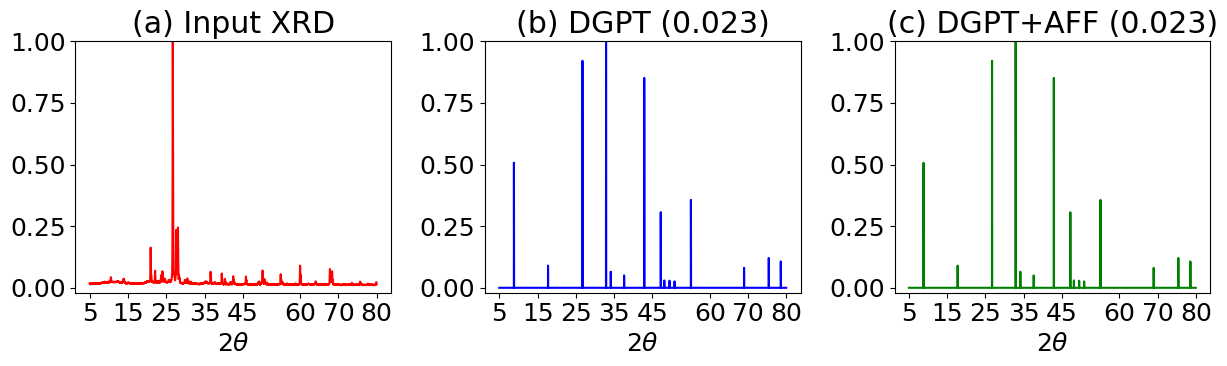

In [11]:
%%time
# https://www.ctcms.nist.gov/~knc6/static/JARVIS-DFT/JVASP-19821.xml
from jarvis.io.vasp.inputs import Poscar
pos="""LaB6
1.0
4.154998579020728 0.0 0.0
0.0 4.154998579020728 -0.0
0.0 0.0 4.154998579020728
La B
1 6
Cartesian
0.0 0.0 0.0
3.3248945674454897 2.0775 2.0775
0.8301054325545105 2.0775 2.0775
2.0775 2.0775 3.3248945674454897
2.0775 2.0775 0.8301054325545105
2.0775 0.8301054325545105 2.0775
2.0775 3.3248945674454897 2.0775
"""
atoms=Poscar.from_string(pos).atoms
#y_new_str,cccc =  smooth_xrd(atoms=atoms,intvl=0.3,thetas=[0,90])
cccc = [];
cccc = np.loadtxt("/content/cccc.txt")
y_new_str =str(cccc)
cccc = np.array(cccc)

print(cccc)
print(y_new_str)
main_spectra(model=model,spectra=[[y_new_str,cccc]],formulas=["SiO2"],tokenizer=tokenizer,filename=None,calculator=None)

response 
4.30 4.30 4.30
60 60 60
Si 0.000 0.000 0.000
Si 0.250 0.250 0.250
System
1.0
3.72391 0.0 2.15
1.2413 3.51094 2.15
0.0 0.0 4.3
Si 
2 
direct
0.0 0.0 0.0 Si
0.25 0.25 0.25 Si

CPU times: user 13.7 s, sys: 4.76 s, total: 18.5 s
Wall time: 18.7 s


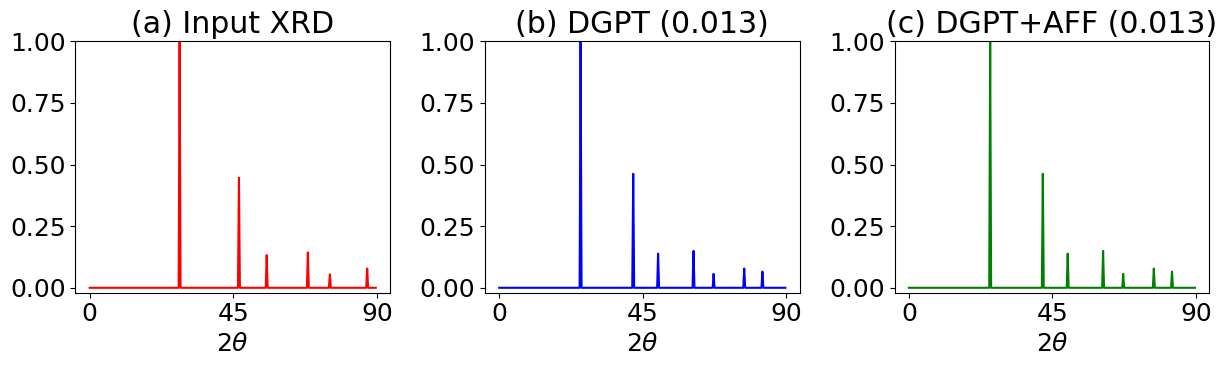

In [ ]:
%%time
# https://www.ctcms.nist.gov/~knc6/static/JARVIS-DFT/JVASP-1002.xml
from jarvis.io.vasp.inputs import Poscar
pos="""Si2
1.0
3.3641499856336465 -2.5027128e-09 1.94229273881412
1.121382991333525 3.1717517190189715 1.9422927388141193
-2.5909987e-09 -1.8321133e-09 3.884586486670313
Si
2
Cartesian
3.92483875 2.77528125 6.7980237500000005
0.56069125 0.39646875 0.9711462500000001
"""
atoms=Poscar.from_string(pos).atoms
y_new_str,cccc = smooth_xrd(atoms=atoms,intvl=0.3,thetas=[0,90])
main_spectra(model=model,spectra=[[y_new_str,cccc]],formulas=["Si"],tokenizer=tokenizer,filename=None,calculator=None)